# Análisis Exploratorio de Datos | Telco Customer Churn

**Elaborado por:** Nino Cabrera y Tiffany Mendoza


## 1. Introducción y contexto

### Objetivo general
Construir un modelo de clasificación binaria para predecir si un cliente de una empresa de telecomunicaciones abandonará el servicio (churn), aplicando prácticas de MLOps con FastAPI, Docker y CI/CD con GitHub Actions.

### Objetivos específicos
- Explorar y comprender la estructura del dataset, identificando distribución del target, valores faltantes y relaciones entre variables
- Preprocesar los datos usando scikit-learn con Pipelines, evitando data leakage
- Entrenar múltiples modelos con GridSearchCV y comparar su desempeño usando AUC-ROC, F1-score, Accuracy y Precision/Recall
- Desplegar el mejor modelo como API REST con FastAPI, contenerizada con Docker

### Contexto
El dataset **Telco Customer Churn** fue publicado en Kaggle y contiene registros de aproximadamente 7,000 clientes de una empresa de telecomunicaciones con variables demográficas, de servicio y de facturación. El objetivo es predecir si un cliente se irá (`Churn = Yes`) o permanecerá (`Churn = No`). La retención de clientes es un problema crítico en telecomunicaciones, donde adquirir un nuevo cliente cuesta entre 5 y 25 veces más que retener uno existente.

## 2. Importación de librerías y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.dpi'] = 100

## 3. Dimensiones del conjunto de datos

Para comenzar, es importante conocer las dimensiones exactas del dataset y los tipos de cada columna.

In [3]:
df = pd.read_csv('../data/telco_churn.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El conjunto de datos contiene 7,043 registros y 21 columnas. No se encontraron valores nulos en ninguna de las variables, lo cual indica que, a primera vista, la base de datos está completa.

## 4. Variable objetivo

Se usará `Churn` como variable objetivo para predecir si un cliente abandona el servicio (`Churn = Yes`) o permanece (`Churn = No`).

In [4]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64


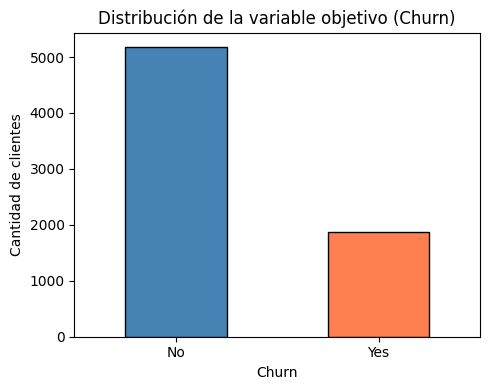

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Distribución de la variable objetivo (Churn)')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

La variable objetivo, Churn, muestra una distribución claramente desbalanceada. La gran mayoría de los clientes, aproximadamente 5,200, pertenecen a la categoría "No", lo que significa que no abandonaron el servicio. En contraste, los clientes que sí hicieron churn (categoría "Yes") son alrededor de 1,800. En términos porcentuales, cerca del 74% de los clientes permanecen en la empresa, mientras que solo un 26% aproximadamente decide cancelar el servicio. Esta diferencia es bastante marcada y representa un desbalance de clases significativo.

Este desbalance es relevante para el modelado, ya que si se entrena un modelo sin tomar ninguna precaución, podría inclinarse a predecir siempre la clase mayoritaria ("No") y aun así obtener una exactitud aparentemente alta, pero fallaría en detectar a los clientes que realmente van a abandonar el servicio, que son justamente los casos de mayor interés para el negocio.

## 5. Inspección general

In [6]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
display(df.dtypes.to_frame(name='tipo').T)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
tipo,object,object,int64,object,object,int64,object,object,object,object,...,object,object,object,object,object,object,object,float64,object,object


El dataset contiene una columna de identificación llamada customerID, la cual asigna un código único a cada cliente y no aporta valor predictivo, por lo que debería excluirse al momento de entrenar un modelo.

Las variables numéricas identificadas son tres: tenure, que representa los meses de permanencia del cliente; MonthlyCharges, que indica el cobro mensual en dólares; y SeniorCitizen, que aunque está codificada como número entero (0 y 1), en realidad es una variable categórica binaria que indica si el cliente es adulto mayor o no.

El resto de las columnas son de tipo categórico. Entre ellas se encuentran datos demográficos como gender, Partner y Dependents, y también información sobre los servicios contratados, como PhoneService, InternetService, OnlineSecurity, TechSupport, StreamingTV y StreamingMovies, entre otros. Además, se incluyen detalles del contrato como Contract, PaperlessBilling y PaymentMethod.

Llama la atención el caso de la columna TotalCharges, ya que aparece como tipo objeto a pesar de que, por su nombre, se esperaría que fuera un valor numérico. Esto podría indicar que contiene caracteres especiales o espacios que impiden que sea reconocida correctamente como número, y sería necesario revisarla más a fondo.

## 6. Valores faltantes

In [8]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

resumen_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje (%)': porcentaje})
display(resumen_faltantes)

,faltantes,porcentaje (%)
customerID,0,0.00
DeviceProtection,0,0.00
TotalCharges,0,0.00
MonthlyCharges,0,0.00
PaymentMethod,0,0.00
PaperlessBilling,0,0.00
Contract,0,0.00
StreamingMovies,0,0.00
StreamingTV,0,0.00
TechSupport,0,0.00


En este caso, el dataset no presenta valores faltantes.

## 7. Medidas básicas

Las medidas de tendencia central como la media, mediana y desviación estándar muestran cómo se comportan las variables numéricas del dataset.

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,"7,043.00",0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75


La variable SeniorCitizen tiene una media de 0.16, lo que indica que solo el 16% de los clientes son adultos mayores. Su desviación estándar es baja (0.37) y sus valores van de 0 a 1, lo cual es esperable por ser una variable binaria. No se observan valores sospechosos en esta columna.

En cuanto a tenure, que mide los meses de permanencia, se observa un rango amplio que va desde 0 hasta 72 meses. La media es de 32.37 meses, pero la mediana es de 29, lo que sugiere una distribución con cierta asimetría. El valor mínimo de 0 llama la atención, ya que indicaría clientes que acaban de ingresar y llevan menos de un mes en la empresa. Esto es posible y tiene sentido, pero vale la pena considerar que esos clientes con tenure igual a 0 pueden tener un comportamiento distinto al resto. Además, el valor máximo de 72 meses equivale a 6 años, lo cual parece razonable y no resulta sospechoso.

Finalmente, la variable MonthlyCharges tiene el cargo mensual promedio es de 64.76 dólares, con una desviación estándar alta de 30.09, lo que refleja una dispersión considerable en los precios. El valor mínimo es de 18.25 dólares y el máximo alcanza los 118.75 dólares. La mediana es de 70.35, superior a la media, lo que indica que hay más clientes concentrados en cobros altos pero algunos valores bajos jalan la media hacia abajo. No se detectan valores atípicos evidentes en esta variable a simple vista, aunque el rango es amplio y podría explorarse más adelante con gráficos.


## 8. Verificación de errores

El dataset de Telco Churn tiene una particularidad conocida: la columna `TotalCharges` viene como string en lugar de numérico, y los clientes nuevos (tenure=0) tienen `TotalCharges` vacío.

In [10]:
# Verificar tipo y valores problemáticos en TotalCharges
print('Tipo de TotalCharges:', df['TotalCharges'].dtype)

if df['TotalCharges'].dtype == object:
    espacios = df[df['TotalCharges'].str.strip() == ''].shape[0]
    print(f'Valores vacíos (espacios) en TotalCharges: {espacios}')

Tipo de TotalCharges: object
Valores vacíos (espacios) en TotalCharges: 11


In [11]:
# Convertir TotalCharges a numérico — los espacios vacíos se vuelven NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('NaN en TotalCharges tras conversión:', df['TotalCharges'].isnull().sum())

NaN en TotalCharges tras conversión: 11


In [12]:
# Los NaN corresponden a clientes con tenure=0 (clientes nuevos sin cargos)
# Se imputan con 0 porque es el valor lógicamente correcto
if 'tenure' in df.columns:
    display(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('NaN restantes en TotalCharges:', df['TotalCharges'].isnull().sum())

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


NaN restantes en TotalCharges: 0


In [13]:
# Convertir Churn a binario (0/1) para facilitar el análisis numérico
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'Filas finales del dataset: {df.shape[0]}')
print('Churn convertido:', df['Churn'].value_counts().to_dict())

Filas finales del dataset: 7043
Churn convertido: {0: 5174, 1: 1869}


Se encontró que existen 11 registros donde el valor de TotalCharges es un espacio en blanco. Todos estos casos corresponden a clientes con tenure igual a 0, es decir, clientes nuevos que aún no han completado su primer mes en la empresa y, por lo tanto, no tienen un cargo total acumulado. Al intentar convertir la columna a formato numérico, esos 11 espacios vacíos se transformaron automáticamente en valores nulos (NaN), lo cual era de esperarse. Después de la conversión, se verificó que no quedaran más valores nulos en el resto del dataset, confirmando que los únicos datos faltantes son esos 11 casos.

Para finalizar la limpieza, se realizaron dos acciones importantes. Primero, se convirtió la variable Churn a un formato numérico binario, asignando 0 a los clientes que no abandonaron el servicio y 1 a los que sí lo hicieron, lo que facilita su uso en modelos de machine learning. El conteo final muestra 5,174 clientes en la categoría "No" y 1,869 en la categoría "Yes", manteniendo el desbalance observado anteriormente. El dataset conserva sus 7,043 filas originales, ahora con TotalCharges corregida y Churn transformada.

## 9. Métricas de dispersión (IQR)

El IQR (rango intercuartílico) permite identificar qué tan dispersos están los datos y detectar posibles valores atípicos.

In [14]:
cols_num = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[cols_num].quantile(0.25)
Q3 = df[cols_num].quantile(0.75)
IQR = Q3 - Q1

iqr_df = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR})
display(iqr_df)

,Q1,Q3,IQR
SeniorCitizen,0.00,0.00,0.00
tenure,9.00,55.00,46.00
MonthlyCharges,35.50,89.85,54.35
TotalCharges,398.55,"3,786.60","3,388.05"
Churn,0.00,1.00,1.00


SeniorCitizen tiene un IQR de 0.00, ya que al ser una variable binaria con pocos valores positivos, la mayoría de los datos se concentran en 0 y no presenta dispersión. Tenure muestra un Q1 de 9 meses y un Q3 de 55 meses, con un IQR de 46 meses. Esto indica que el 50% central de los clientes tiene una permanencia que varía entre 9 y 55 meses, reflejando una dispersión considerable. MonthlyCharges presenta un Q1 de 35.50 dólares y un Q3 de 89.85 dólares, con un IQR de 54.35 dólares. Esta amplitud indica que los cobros mensuales varían notablemente entre clientes, según los servicios contratados. TotalCharges es la variable con mayor variabilidad, con un Q1 de 398.55 dólares y un Q3 de 3,786.60 dólares, resultando en un IQR de 3,388.05 dólares. Esta dispersión tan amplia combina la variabilidad de la permanencia y del cobro mensual. Churn tiene un IQR de 1.00 por ser una variable binaria, lo cual no refleja dispersión real en el sentido tradicional.

## 10. Análisis Univariado

### 10.1 Variables numéricas

Los histogramas permiten observar la distribución de cada variable numérica e identificar sesgos o valores atípicos.

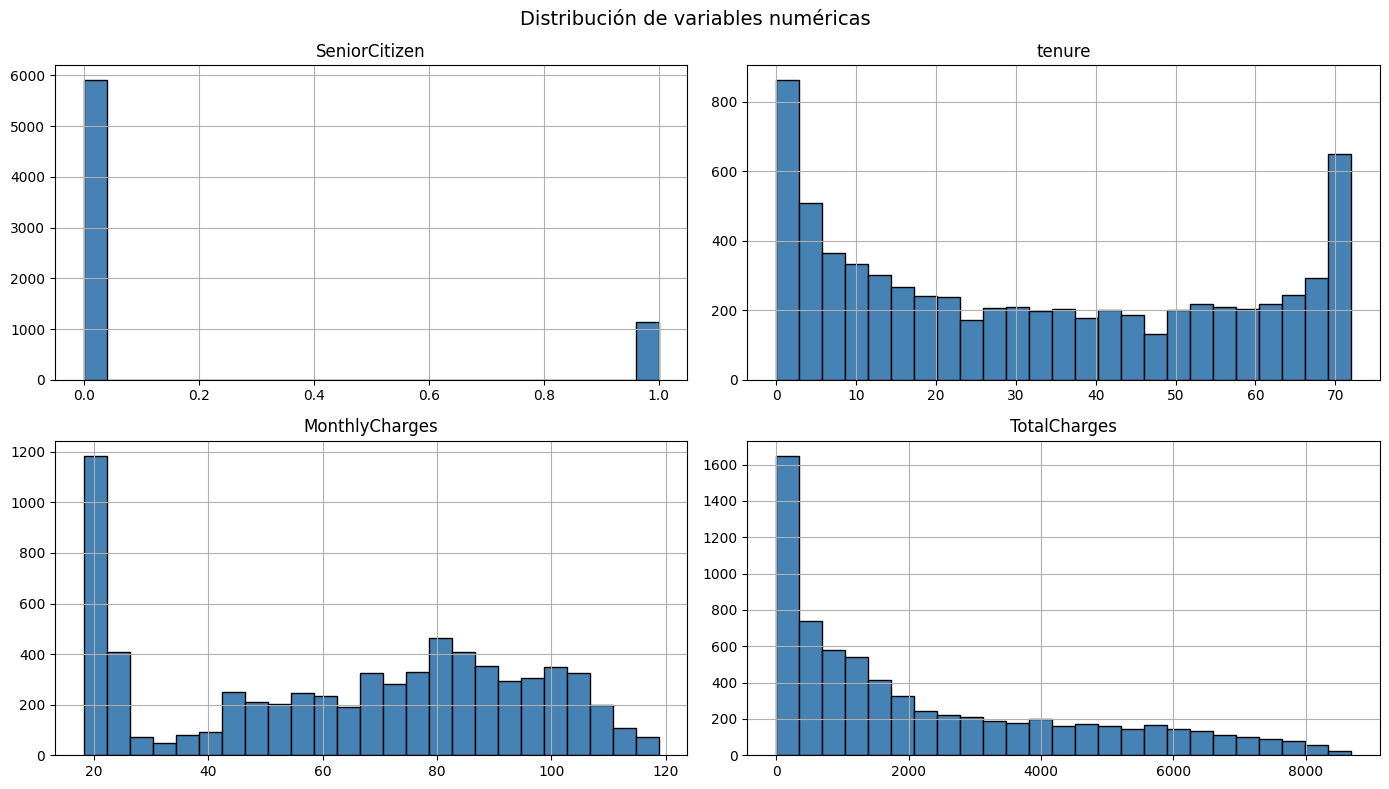

In [15]:
numericas = df.select_dtypes(include='number').drop(columns=['Churn']).columns

df[numericas].hist(bins=25, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

SeniorCitizen muestra una distribución extremadamente asimétrica con una concentración casi total en el valor 0, cerca del 84% de los clientes no son adultos mayores, solo el 16% pertenece a esta categoría, lo que genera un sesgo muy marcado hacia la izquierda. Tenure presenta una distribución peculiar con concentraciones en ambos extremos, hay una cantidad importante de clientes con valores bajos cercanos a 0, lo que indica que muchos son relativamente nuevos, en el otro extremo también se observa una acumulación notable en el valor máximo de 72 meses, lo que sugiere un grupo significativo de clientes muy antiguos, la zona intermedia tiene menor concentración, dándole a la distribución una forma casi de U. MonthlyCharges tiene una distribución que se concentra principalmente en dos zonas, hay un grupo numeroso con cobros bajos alrededor de 20 dólares y otro grupo grande con cobros altos cerca de los 80 a 100 dólares, la zona central alrededor de 50 a 70 dólares tiene menor frecuencia, esto genera una distribución con cierta bimodalidad sin una asimetría clara hacia un solo lado. TotalCharges muestra una distribución fuertemente sesgada hacia la izquierda, la mayoría de los clientes tienen valores bajos concentrándose en los primeros intervalos, lo que refleja que muchos clientes tienen poca antigüedad, a medida que aumentan los valores las frecuencias disminuyen de forma progresiva formando una cola larga hacia la derecha donde pocos clientes alcanzan los montos más altos.

### 10.2 Variables categóricas

Se analizan las frecuencias de cada variable categórica para entender cómo están compuestas.

In [16]:
categoricas = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas ({len(categoricas)}): {categoricas}')

Variables categóricas (16): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


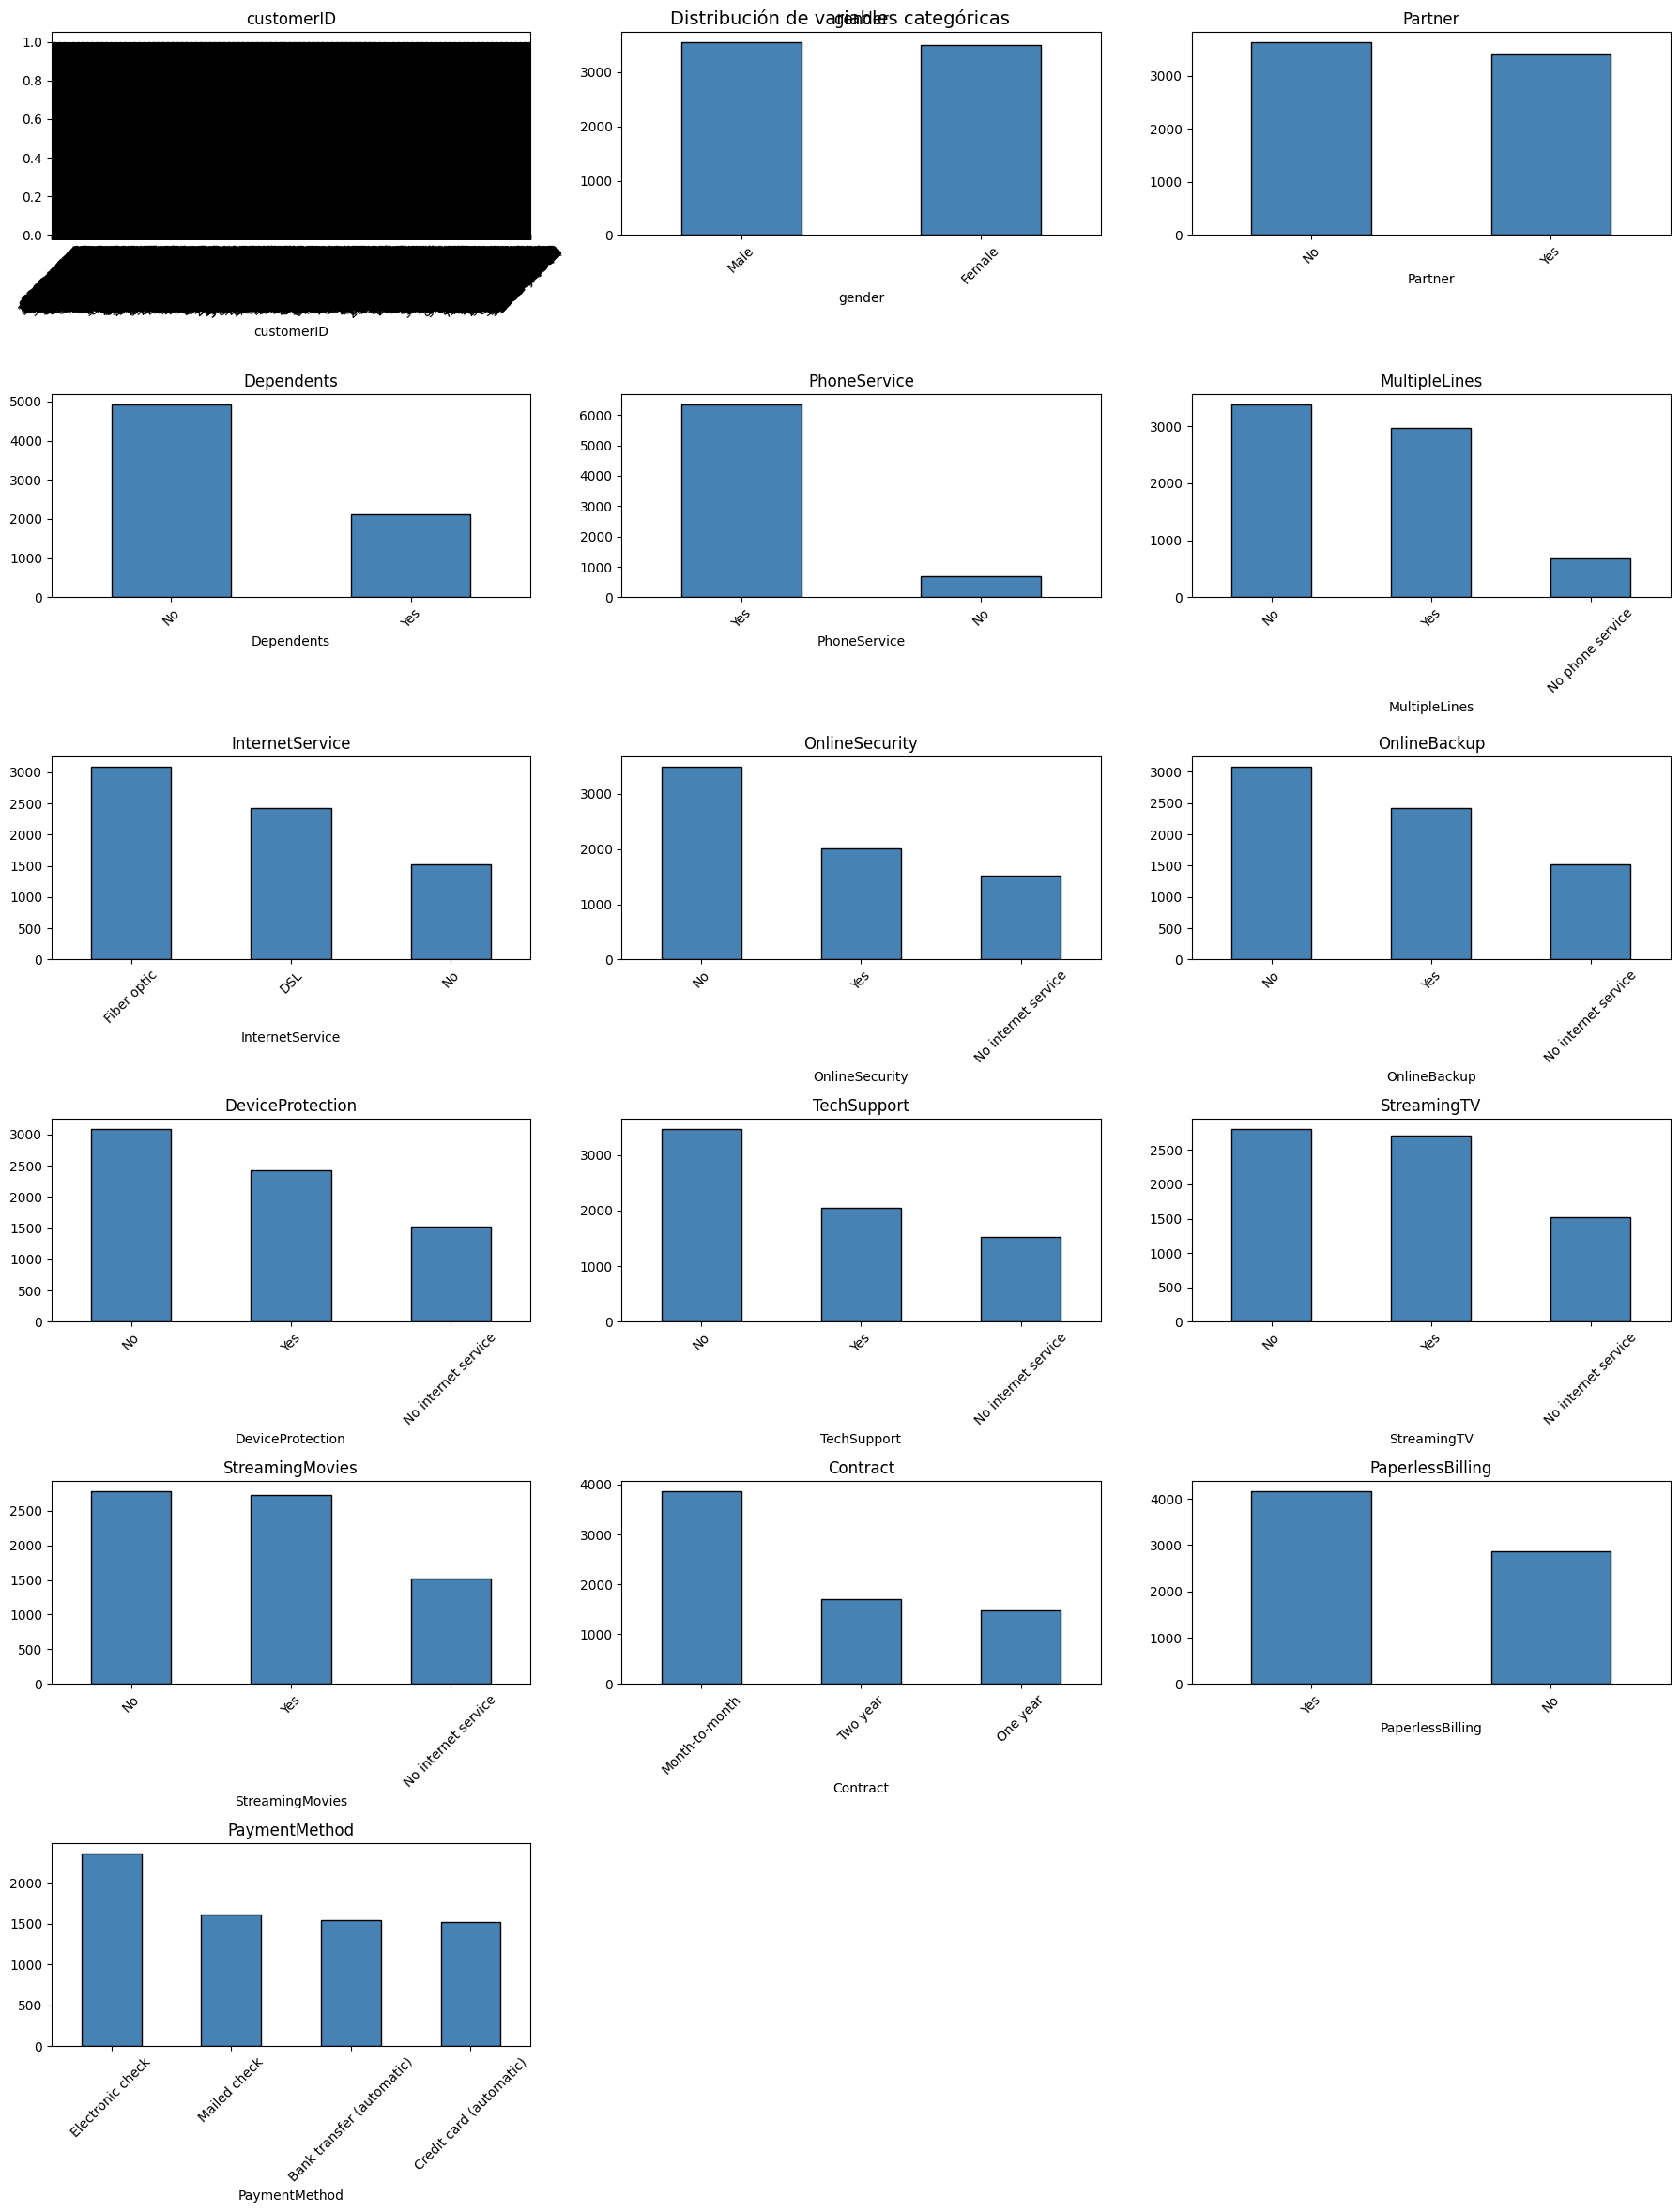

In [17]:
n_cols = 3
n_rows = (len(categoricas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

El dataset contiene múltiples variables categóricas que en su mayoría presentan distribuciones desbalanceadas. En las variables demográficas, gender se distribuye de forma casi equitativa entre hombres y mujeres, mientras que Partner y Dependents muestran una mayoría de clientes sin pareja y sin dependientes respectivamente. En cuanto a los servicios telefónicos, PhoneService está presente en la gran mayoría de los clientes, pero MultipleLines se inclina hacia la opción "No" seguida de cerca por "Yes", con una minoría que no aplica por no tener servicio telefónico. InternetService se reparte principalmente entre Fibra óptica y DSL, con un grupo pequeño sin servicio de internet. Los servicios adicionales como OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV y StreamingMovies presentan un patrón similar, la categoría "No" domina en todas ellas, lo que indica que la mayoría de los clientes no contrata estos complementos, mientras que "Yes" aparece en menor proporción y en algunos casos existe la categoría "No internet service" para quienes no tienen internet contratado. En las variables contractuales, Contract muestra un predominio de contratos mes a mes, seguido por contratos de un año y finalmente de dos años con menor representación. PaperlessBilling está inclinado hacia el "Yes", lo que indica que la mayoría opta por facturación digital. PaymentMethod se distribuye principalmente en cuatro métodos, siendo la transferencia bancaria automática y la tarjeta de crédito los más frecuentes, seguidos por el cheque electrónico y el cheque por correo con menor presencia.

## 11. Análisis Multivariado

### 11.1 Boxplot por clase (Churn)

Se compara la distribución de cada variable numérica entre clientes que hacen churn (1) y los que no (0).

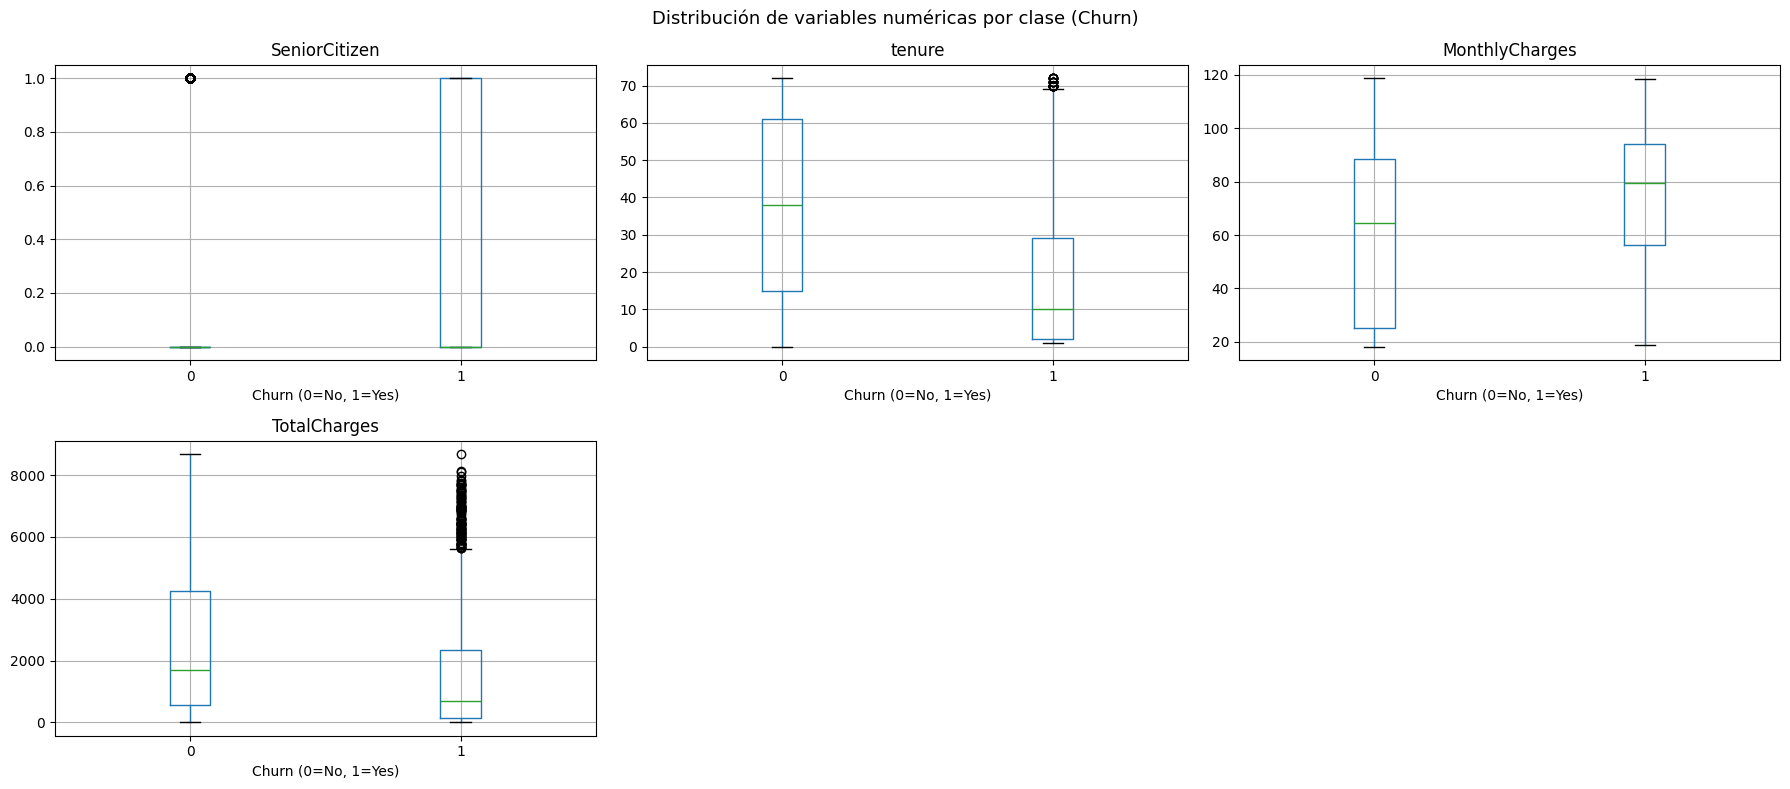

In [18]:
numericas = df.select_dtypes(include='number').drop(columns=['Churn']).columns

n_cols = 3
n_rows = (len(numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por clase (Churn)', fontsize=13)
plt.tight_layout()
plt.show()

Las variables numéricas muestran diferencias notables entre los clientes que abandonan el servicio y los que permanecen. SeniorCitizen no presenta una diferencia tan marcada, aunque la proporción de adultos mayores es ligeramente superior entre los que hacen churn. Tenure es la variable con mayor poder discriminativo, los clientes que no abandonan tienen una permanencia promedio mucho más alta, alrededor de 38 meses, mientras que los que hacen churn apenas alcanzan una media cercana a los 10 meses, lo que indica que los clientes nuevos son mucho más propensos a cancelar. MonthlyCharges también muestra una diferencia clara en sentido opuesto, los clientes que hacen churn pagan en promedio cerca de 75 dólares mensuales, frente a unos 60 dólares de los que se quedan, lo que sugiere que los cobros más altos están asociados con mayor abandono. TotalCharges refleja una diferencia similar a tenure, los clientes leales acumulan un total mucho más alto por su mayor antigüedad, mientras que los que abandonan tienen totales bajos debido a su corta permanencia, por lo que esta variable es más un reflejo de tenure que un factor discriminativo independiente. En conjunto, tenure y MonthlyCharges son las variables numéricas con mayor capacidad para diferenciar entre clientes que hacen churn y los que no.

### 11.2 Tasa de churn por variable categórica

Se calcula la tasa de churn promedio dentro de cada categoría para identificar cuáles están más asociadas al abandono.

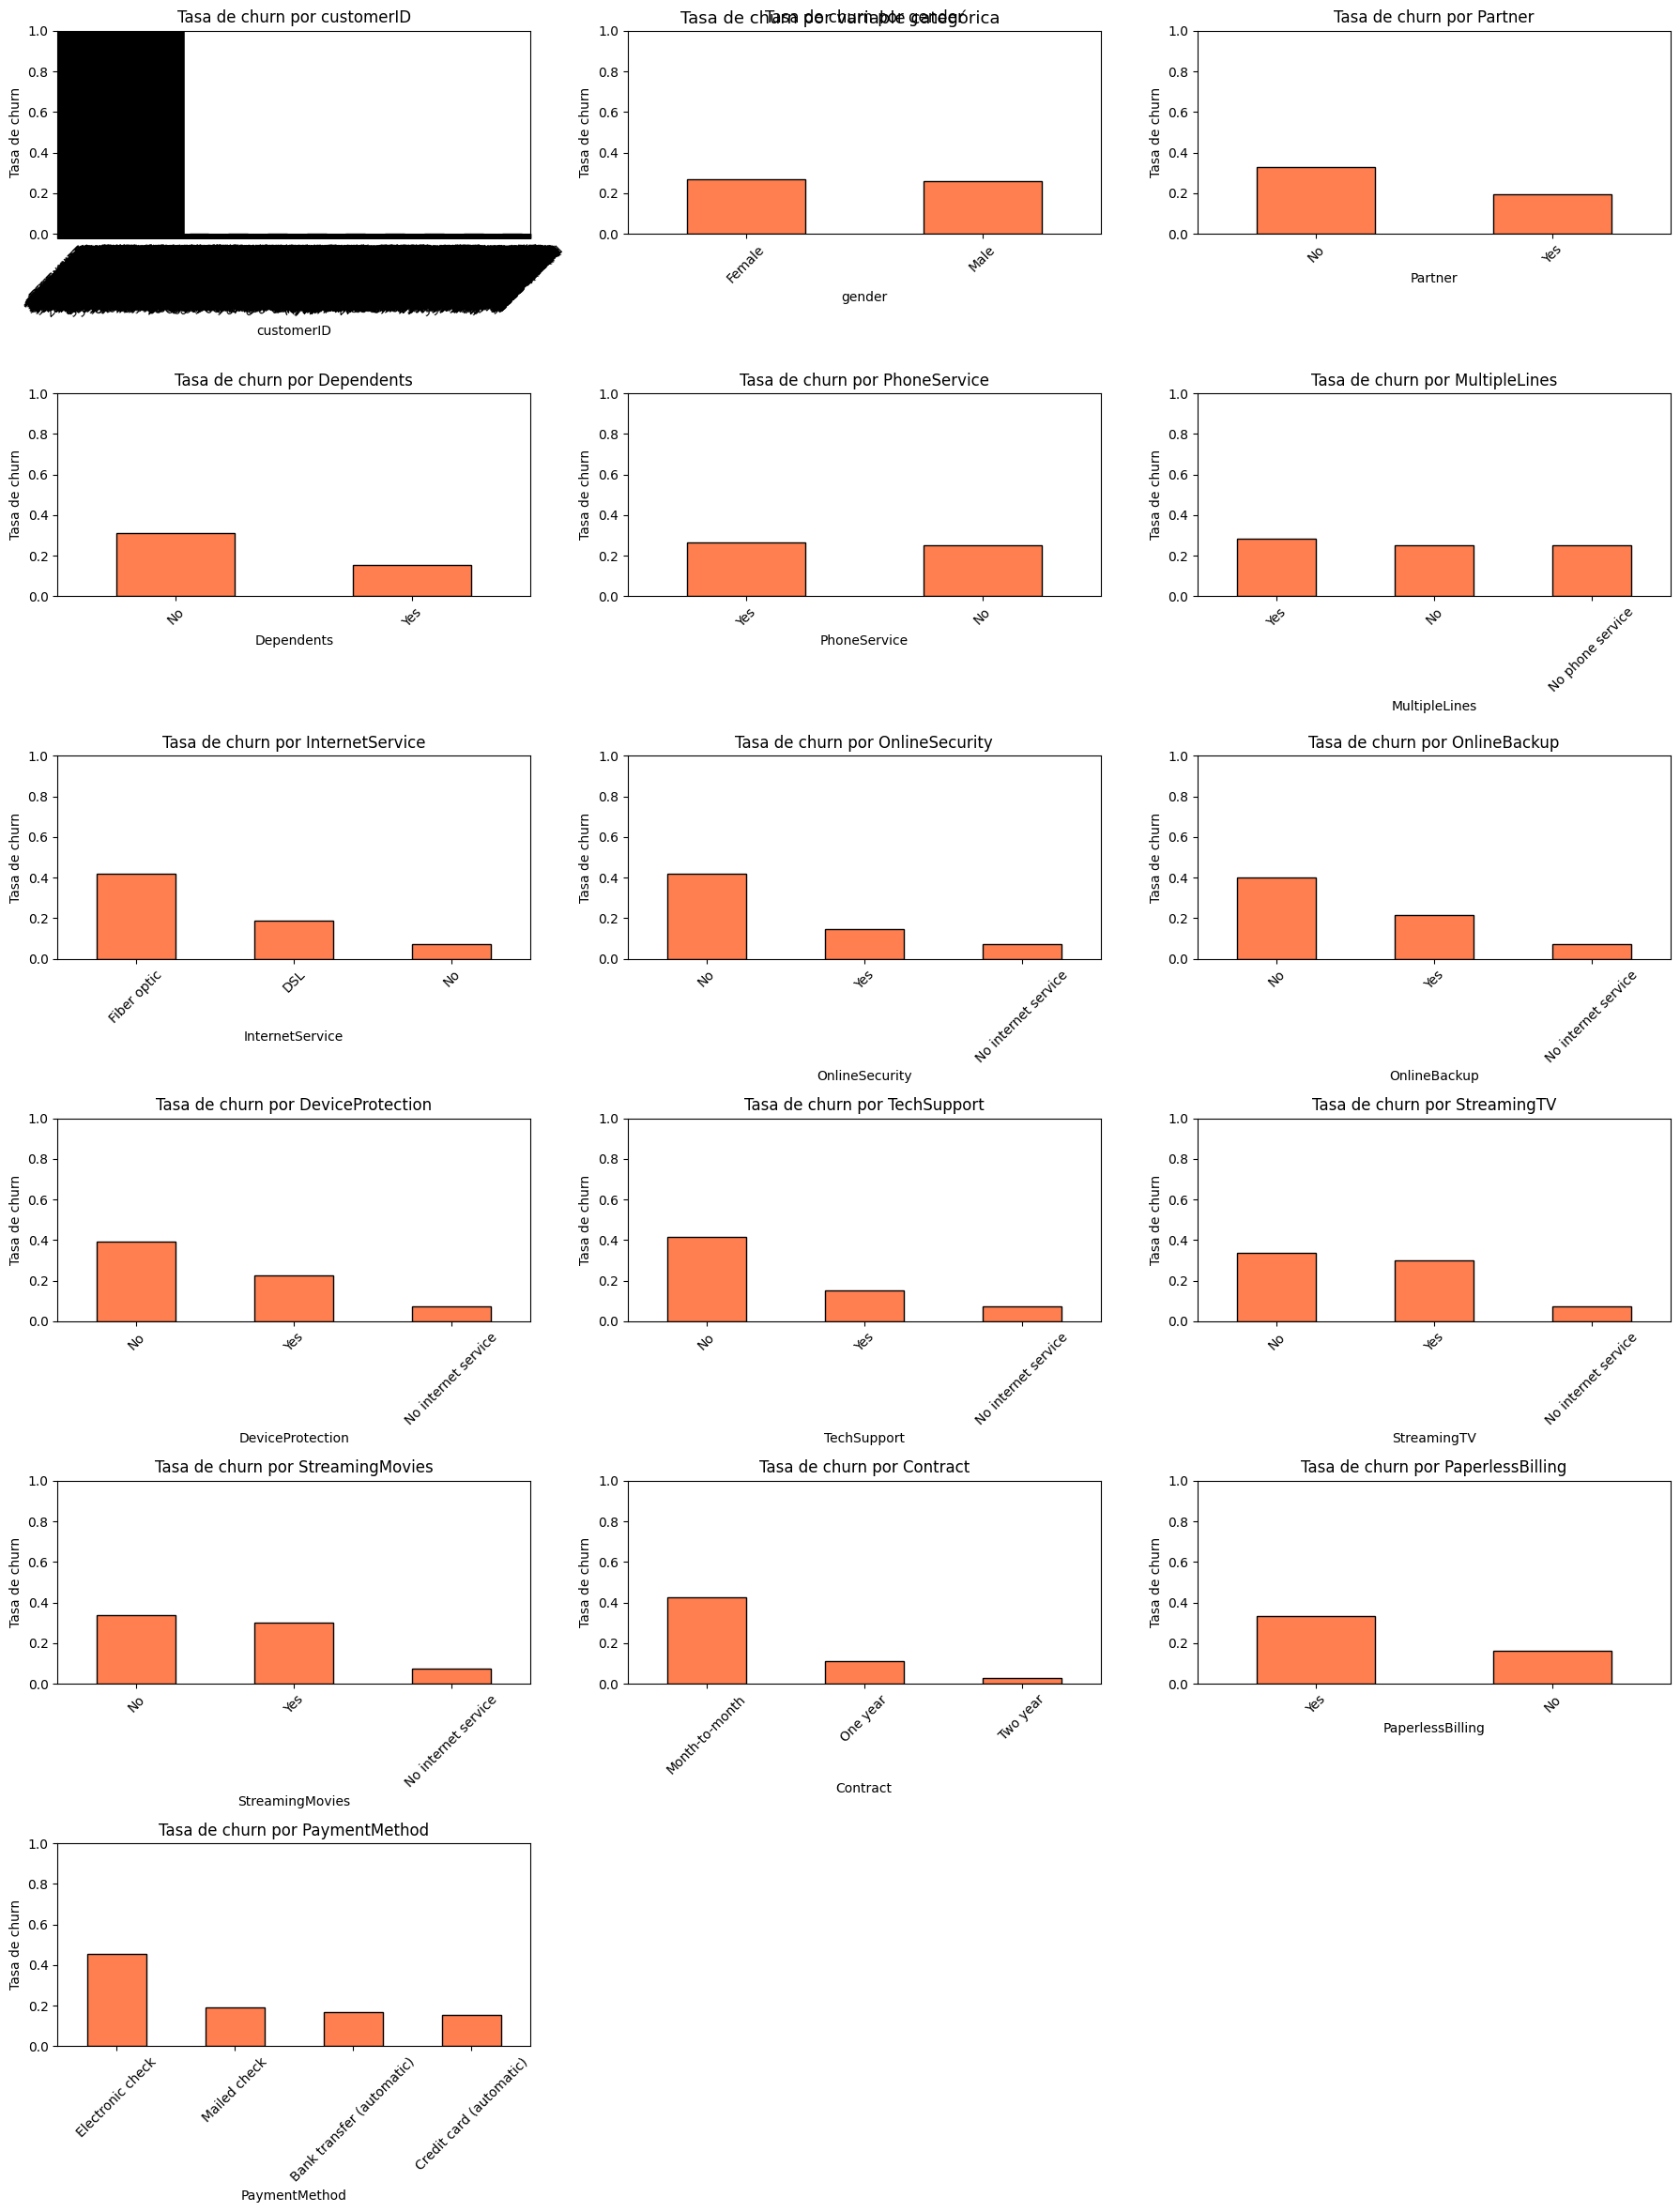

In [19]:
n_cols = 3
n_rows = (len(categoricas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'Tasa de churn por {col}')
    axes[i].set_ylabel('Tasa de churn')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de churn por variable categórica', fontsize=13)
plt.tight_layout()
plt.show()

Las variables categóricas con mayor diferencia en las tasas de churn son Contract, InternetService, OnlineSecurity y TechSupport. Los clientes con contrato mes a mes abandonan mucho más que los de uno o dos años. Los que usan fibra óptima tienen tasas de churn más altas que los de DSL, los de fibra óptica abandonan más. Quienes no contratan seguridad en línea ni soporte técnico también presentan mayor abandono. En las variables demográficas, los clientes sin pareja y sin dependientes tienen tasas de churn más elevadas. PaperlessBilling muestra más churn en quienes usan facturación digital. PaymentMethod indica que el cheque electrónico concentra las tasas más altas de abandono. Gender y PhoneService no muestran diferencias relevantes.

### 11.3 Correlación entre variables numéricas

La matriz de correlación muestra las relaciones lineales entre variables numéricas y la variable objetivo.

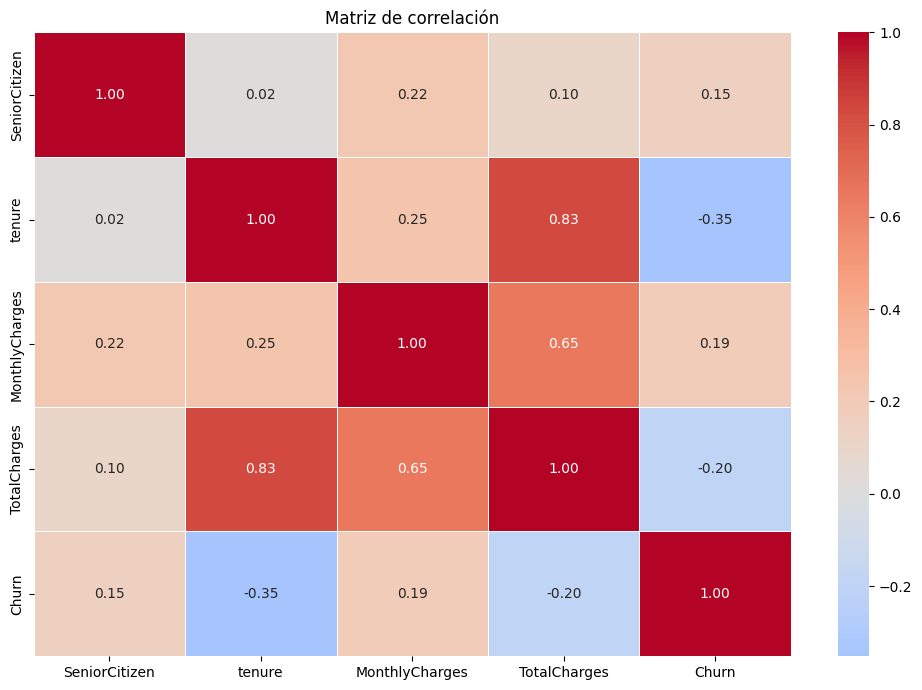

In [20]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

La matriz de correlaciones muestra que tenure es la variable con la relación más fuerte con Churn, con un valor negativo de -0.35, lo que indica que a mayor permanencia menor es la probabilidad de abandono. MonthlyCharges tiene una correlación positiva de 0.19 con Churn, a mayor cobro mensual mayor probabilidad de fuga, aunque la relación es más débil. SeniorCitizen apenas muestra correlación con Churn, con un valor cercano a 0.15, siendo la variable numérica con menor vínculo con la variable objetivo. TotalCharges presenta una correlación negativa de -0.20 con Churn, pero este valor está influenciado por su fuerte relación con tenure.

Entre las variables predictoras se detecta una correlación muy alta entre tenure y TotalCharges de 0.83, lo cual es esperable porque los cargos totales dependen directamente del tiempo de permanencia. Esto genera un problema de multicolinealidad, ambas variables aportan información redundante y no deberían usarse juntas en ciertos modelos sin considerar este efecto. MonthlyCharges y TotalCharges también muestran una correlación moderada de 0.65, ya que los clientes con más antigüedad y cobros altos acumulan totales elevados. SeniorCitizen no presenta correlaciones relevantes con ninguna otra variable numérica, manteniéndose por debajo de 0.22 en todos los casos.

## Conclusiones del EDA

El análisis exploratorio permitió identificar varios hallazgos relevantes para el modelado posterior. La variable objetivo Churn presenta un desbalance de clases significativo, con aproximadamente un 74% de clientes que no abandonan el servicio frente a un 26% que sí lo hace, lo que obligará a aplicar técnicas de balanceo y a priorizar métricas como el recall o el F1-score sobre la exactitud.

Las variables con mayor poder discriminativo fueron tenure y MonthlyCharges entre las numéricas, y Contract, InternetService, OnlineSecurity y TechSupport entre las categóricas. Los clientes con poca antigüedad, contratos mes a mes, fibra óptica y sin servicios de soporte técnico o seguridad en línea presentan las tasas de churn más elevadas. Las variables familiares Partner y Dependents también mostraron influencia, con mayor abandono en clientes sin pareja y sin dependientes.

En la limpieza de datos se encontró que la columna TotalCharges estaba almacenada como texto debido a 11 registros con espacios vacíos, correspondientes a clientes con tenure igual a 0. Estos valores se convirtieron a nulos y se mantuvieron en el dataset sin imputar por representar información real de clientes nuevos. La variable Churn fue transformada a formato numérico binario.

Se decidió descartar la columna customerID por ser un identificador único sin valor predictivo. La variable TotalCharges se excluirá del modelado por su alta correlación con tenure, lo que genera multicolinealidad y aporta información redundante. SeniorCitizen se conserva pese a su baja correlación con Churn por tratarse de una variable demográfica que podría complementar a otras en el modelo.

Para el pipeline del siguiente notebook se aplicará codificación de variables categóricas, escalado de variables numéricas y una estrategia de balanceo de clases, considerando que la mayoría de las variables presentan distribuciones con desbalances marcados que deben ser tratados adecuadamente.